### Agent 基本使用
- 传入模型
    - 字符串传入
    - 模型对象传入
- 绑定工具
- agent调用

In [4]:

import os
from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langchain_tavily import TavilySearch
from rich import print as rprint

load_dotenv(override=True)

model = init_chat_model(
    model="deepseek:deepseek-v4-flash",
)

#Langchain内置工具
web_search = TavilySearch(
    api_key = os.getenv("TAVILY_API_KEY"),
    max_results=3,
    # 搜索主题(一般general,金融finance,新闻news)
    topic="general"
)

#这是高级用法，后续会详细学习
config = {
"recursion_limit": 15 # 最多 15 步
}

agent = create_agent(
    model = "deepseek:deepseek-v4-flash",
    #model=model,传入模型对象
    tools = [web_search],
)

response = agent.invoke({"messages": [HumanMessage("大数据管理与应用专业,简洁回答")]}, config=config)

rprint(response)

{
    'messages': [
        HumanMessage(
            content='大数据管理与应用专业,简洁回答',
            additional_kwargs={},
            response_metadata={},
            id='16bc4ea2-3318-4803-8ca5-9130af899256'
        ),
        AIMessage(
            content='',
            additional_kwargs={
                'refusal': None,
                'reasoning_content': 'The user is asking about the "大数据管理与应用专业" (Big Data Management and 
Application major) in Chinese, and wants a concise answer. Let me provide information about this major. I could 
search for current info, but this is a well-known Chinese university major. Let me give a concise 
answer.\n\nActually, let me search to provide accurate, current information.'
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 146,
                    'prompt_tokens': 1895,
                    'total_tokens': 2041,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 73,
                        'rejected_prediction_tokens': None
                    },
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1792},
                    'prompt_cache_hit_tokens': 1792,
                    'prompt_cache_miss_tokens': 103
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e',
                'id': '3106d93e-26fb-4e3e-89a2-91a5de116c7e',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0059a-0834-7561-93b9-f2727ffc87c7-0',
            tool_calls=[
                {
                    'name': 'tavily_search',
                    'args': {'query': '大数据管理与应用专业 介绍 课程 就业方向', 'search_depth': 'advanced'},
                    'id': 'call_00_RlW3022crmBe5Mgjdcg59069',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 1895,
                'output_tokens': 146,
                'total_tokens': 2041,
                'input_token_details': {'cache_read': 1792},
                'output_token_details': {'reasoning': 73}
            }
        ),
        ToolMessage(
            content='{"query": "大数据管理与应用专业 介绍 课程 就业方向", "follow_up_questions": null, "answer": 
null, "images": [], "results": [{"url": 
"https://zhaosheng.xaut.edu.cn/zhuanyejieshao/jingjiyuguanlixueyuan/2017-04-10/92.html", "title": 
"大数据管理与应用专业简介", "content": "首页 —— 学院专业 —— 经济与管理学院\\n\\n#### 大数据管理与应用专业简介\\n\\n
时间：2026-06-10 16:10:28\\n 
来源：\\n\\n\ufeff\\n\\n大数据管理与应用专业以第四次工业革命和大数据时代为背景，采用全新的课程教学体系，旨在培养技
术功底扎实、商务素养优良的复合型高素质大数据工程技术人才。主要研究数学、统计学、计算机科学、数据科学、经济学与管理
学基础理论、商务数据建模与决策分析的相关技术、方法，使学生具备运用大数据分析技术和工具对商务大数据开展定噩分析、决
策支持的综合能力。本专业隶属于管理科学与工程一级学科，我校管理科学与工程学科是陕西省重点学科，在教育部学位中心第四
轮学科评估中，被评为B+(全国前20%)。设有管理科学与工程学科硕士、博士一级学科授权点，建有管理科学与工程博士后流动站，
设有杨善林院士工作室。有陕西省实验教学示范中心，设有大数据分析实验室、大数据综合实训室、虚拟仿真实验室等，建有十余
家校外实习实践基地。2025年获批大数据分析与智能决策陕西省高等学校重点实验室。\\n\\n主要课程\\n\\n结合时代背景和国家
需要，本专业开设Python程序设计、面向对象程序设计、大数据采集与清洗、分布式存储与计算、大数据分析、机器学习、人工智
能概论、大数据可视化、数据治理等主干课程，经济学、管理学、运筹学、商务统计学等经管类基础课程，金融大数据分析、文本
分析与文本数据挖掘、社交大数据分析、营销大数据分析、工业大数据建模与分析、水利大数据分析等选修课程。开设案例分析、
实操实训、生产实习、课程设计等综合实践环节。\\n\\n就业方向 [...] 
就业方向\\n\\n该专业为全日制本科，学制4年，学生修完规定课程及学分后，毕业颁发管理学学士学位证书。该专业紧紧围绕国家
社会经济发展重大战略需要，为社会培养急需的大数据工程技术与管理复合型人才，社会需求巨大，学生毕业后就业面广，薪资高
。毕业生能在华为、字节跳动、腾讯、阿里巴巴等知名企业或政府机关、事业单位从事大数据算法设计、大数据工程、商业决策支
持、数字化管理等工作，也可赴高校、研究所继续深造，从事数据科学、人工智能等领域的研究工作，本专业考研升学率超过30%,
深造高校包括中国科学院大学、北京邮电大学、西安电子科技大学、合肥工业大学等“双一流”高校。\\n\\n#### 联系方式\\n\\n 
电话（传真）：029-82312504\\n 邮箱：zhaoban@xaut.edu.cn\\n\\n 邮编：710048\\n 
通信地址：西安市金花南路5号707信箱\\n\\n您是第 位访客\\n\\n 设为首页;)  加入收藏夹;)\\n\\n© 
2017西安理工大学本科招生办公室", "score": 0.93511593, "raw_content": null, "id": "07d84e-00"}, {"url": 
"http

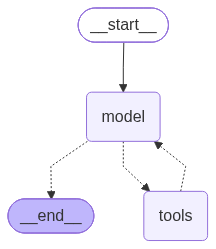

In [2]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))